# Lab 6 — Task 2: Model Explainability (SHAP)

In [4]:
import os
from pathlib import Path

import mlflow
from mlflow.artifacts import download_artifacts
from IPython.display import Image, Markdown, display

EXPERIMENT = "lab6_hyperparameter_tuning"
MLFLOW_URI = os.environ.get("MLFLOW_TRACKING_URI", "http://mlflow:5000")
mlflow.set_tracking_uri(MLFLOW_URI)
client = mlflow.MlflowClient()

MODELS = [
    ("linear_svc",          "grid_search", "LinearSVC"),
    ("logistic_regression", "grid_search", "LogisticRegression"),
    ("multinomial_nb",      "grid_search", "MultinomialNB"),
]

def get_best_run_id(model: str, method: str) -> str:
    exp = client.get_experiment_by_name(EXPERIMENT)
    runs = client.search_runs(
        experiment_ids=[exp.experiment_id],
        filter_string=(
            f'tags.model = "{model}" AND '
            f'tags.method = "{method}" AND '
            f'tags.is_best = "true"'
        ),
        order_by=["attributes.end_time DESC"],
        max_results=1,
    )
    if not runs:
        raise ValueError(f"No best run found for {model} / {method}")
    return runs[0].info.run_id

RUN_IDS = {model: get_best_run_id(model, method) for model, method, _ in MODELS}
for (model, _, label), run_id in zip(MODELS, RUN_IDS.values()):
    print(f"{label:<22} → {run_id}")

def shap_image(model: str, artifact_path: str) -> Image:
    local = download_artifacts(run_id=RUN_IDS[model], artifact_path=f"shap/{artifact_path}")
    return Image(filename=local)

LinearSVC              → bf08e13aa6774d0f95f4699c38fb1e37
LogisticRegression     → c8e82cdb540b49c4a1f83b4f9032ae64
MultinomialNB          → 433dad38ab8f4ac78d0e0799a48d48eb


## 2. Task 2a — SHAP summary per model (beeswarm)

### 2.1 LinearSVC

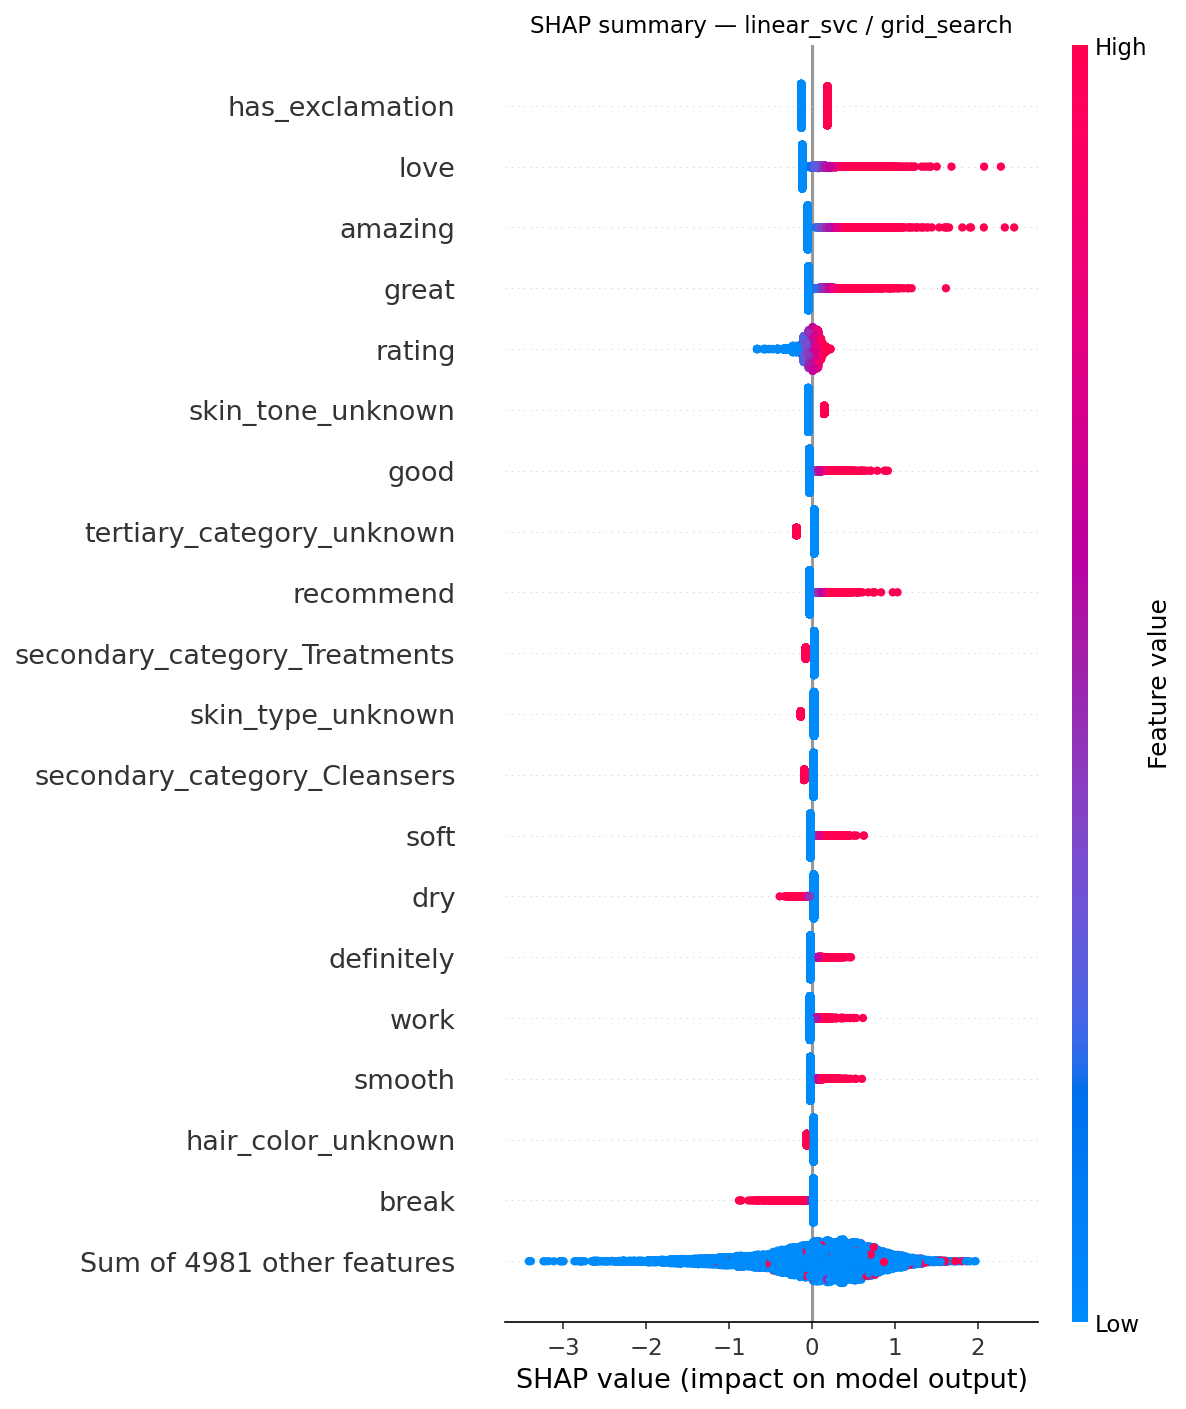

In [5]:
display(shap_image("linear_svc", "summary_beeswarm.png"))

### 2.2 LogisticRegression

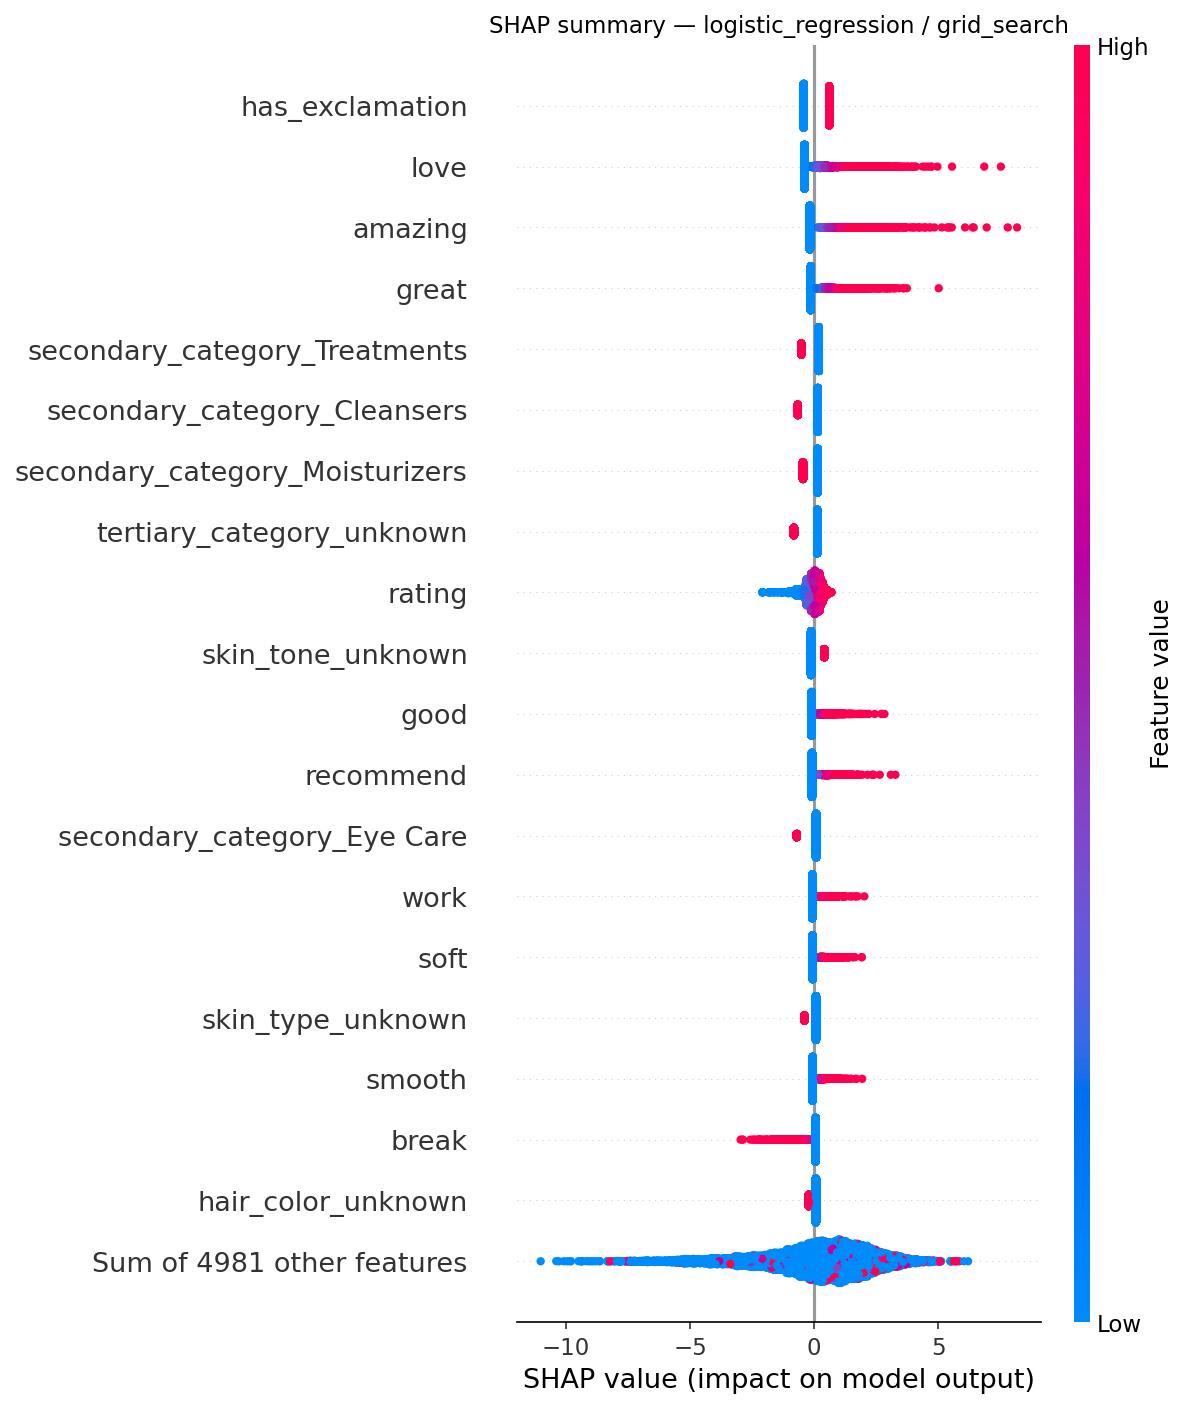

In [6]:
display(shap_image("logistic_regression", "summary_beeswarm.png"))

### 2.3 MultinomialNB

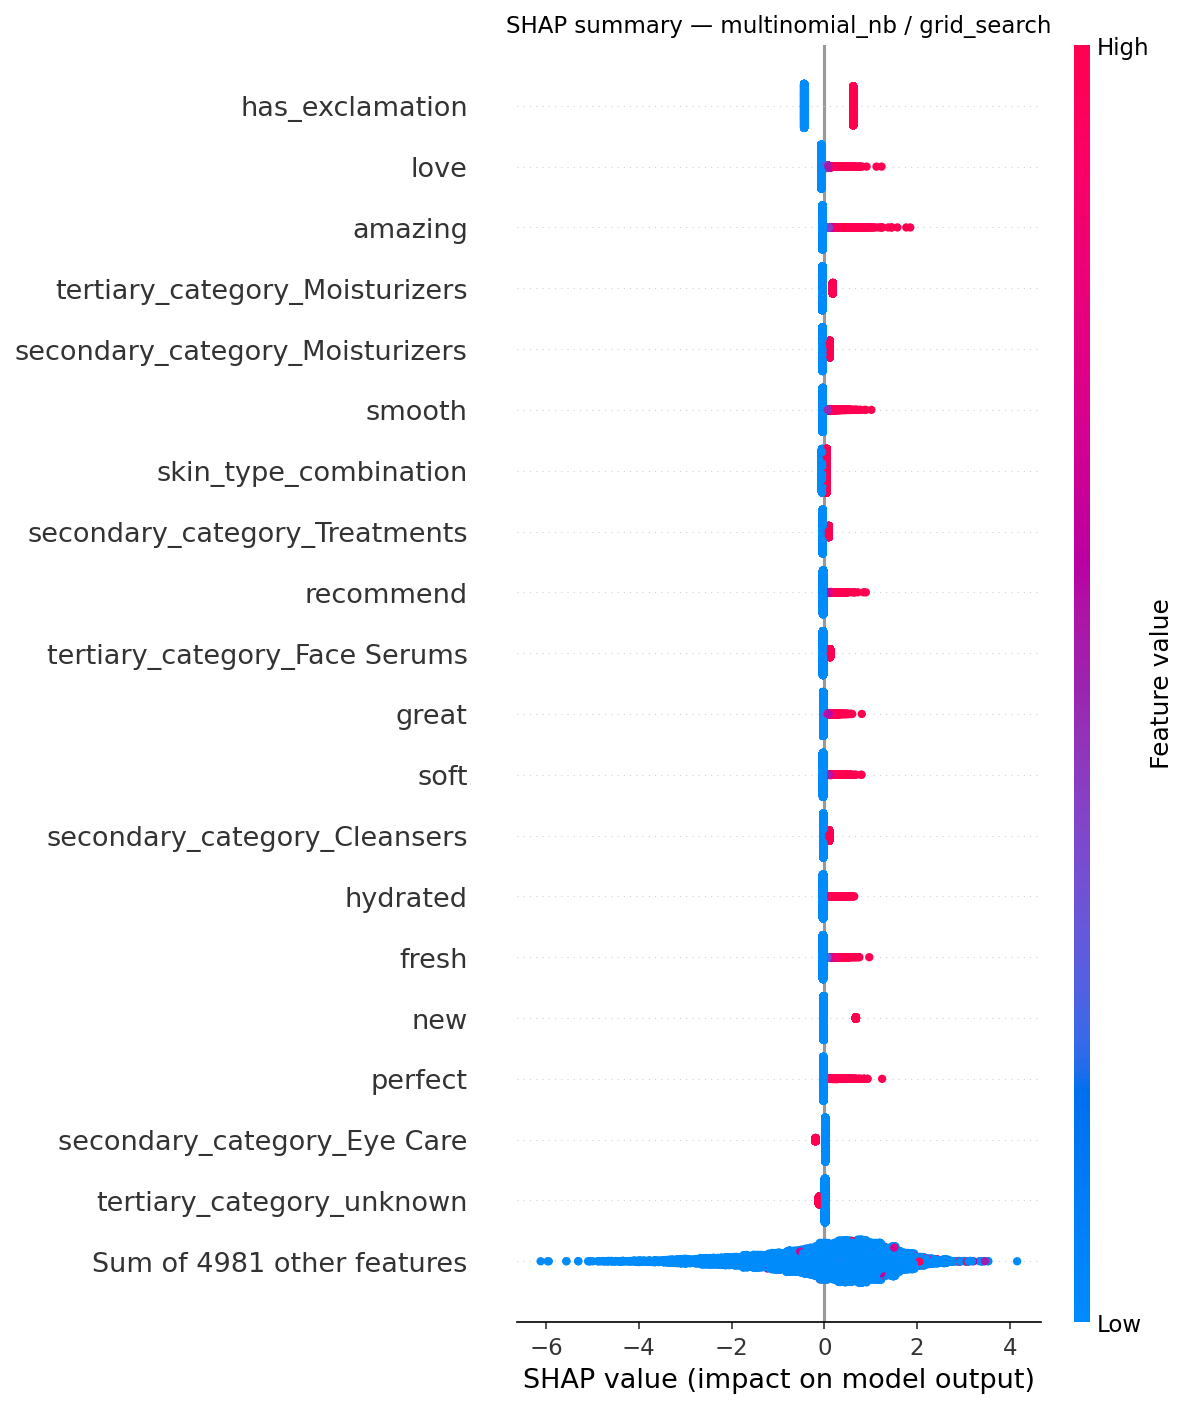

In [7]:
display(shap_image("multinomial_nb", "summary_beeswarm.png"))

### Comparison
**Similarities**: All three models agree that love, amazing, and great are the strongest positive drivers, rating behaves as a key numeric signal, and break is a consistent negative cue.

**Differences**: Logistic Regression produces the most extreme SHAP magnitudes, Linear SVC is the most concentrated on a few top lexical features, and Multinomial NB spreads importance across more tokens and leans more heavily on product-category metadata..

## 3. Task 2b — Positive vs negative features

The bar charts below show the top 20 features by **signed mean SHAP** for each classifier. Blue bars push predictions toward the **positive** sentiment class; red bars push toward the **negative** class. Unlike the beeswarm (which uses `mean |SHAP|`), this view preserves direction, so we can read off which tokens are learned as positive vs negative sentiment drivers.

### 3.1 LinearSVC

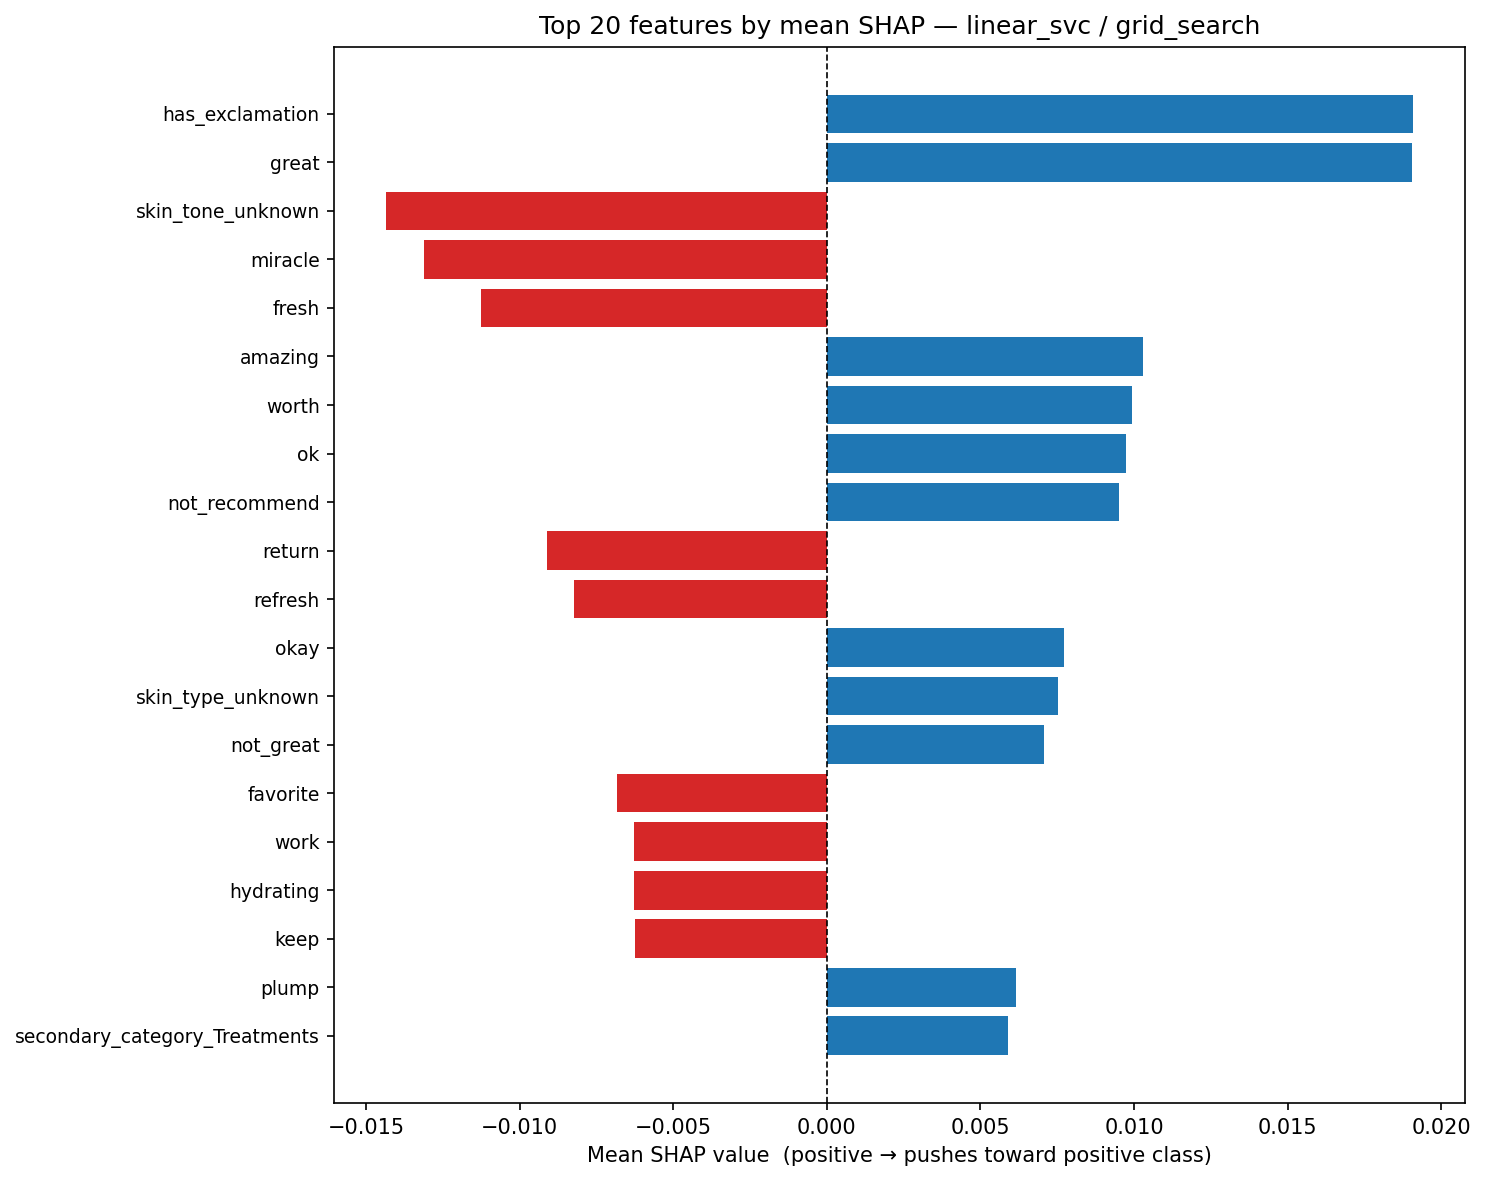

### 3.2 LogisticRegression

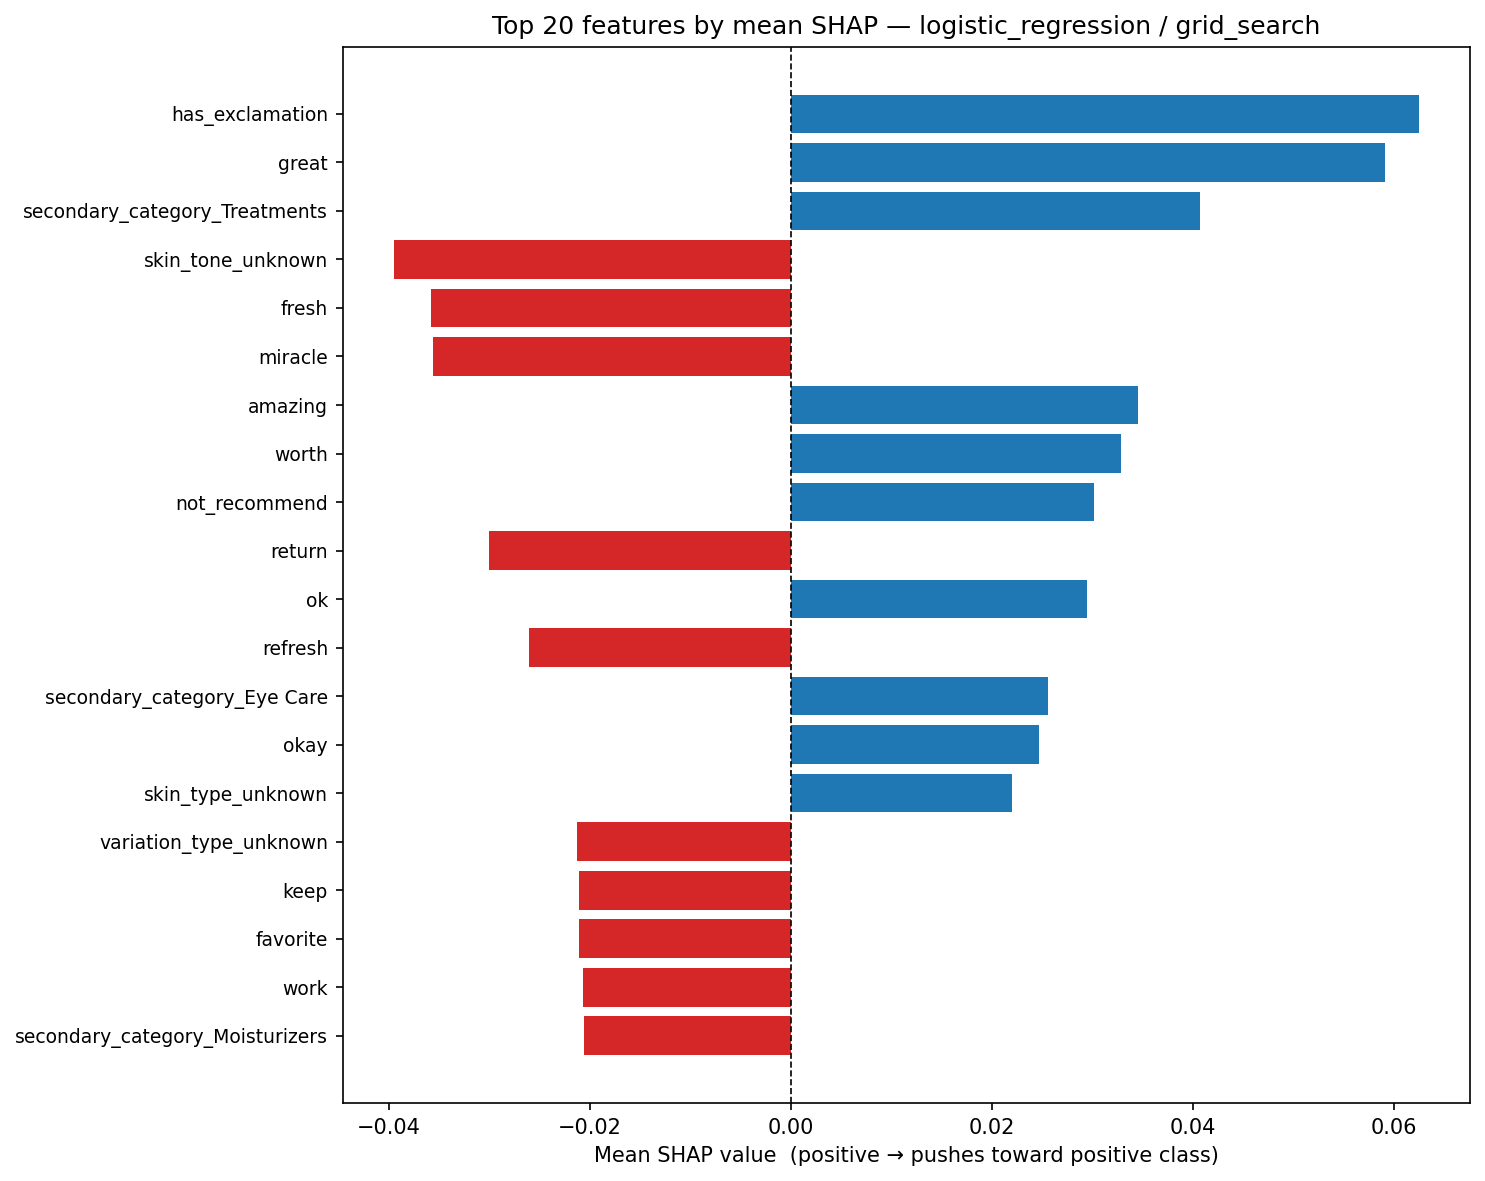

### 3.3 MultinomialNB

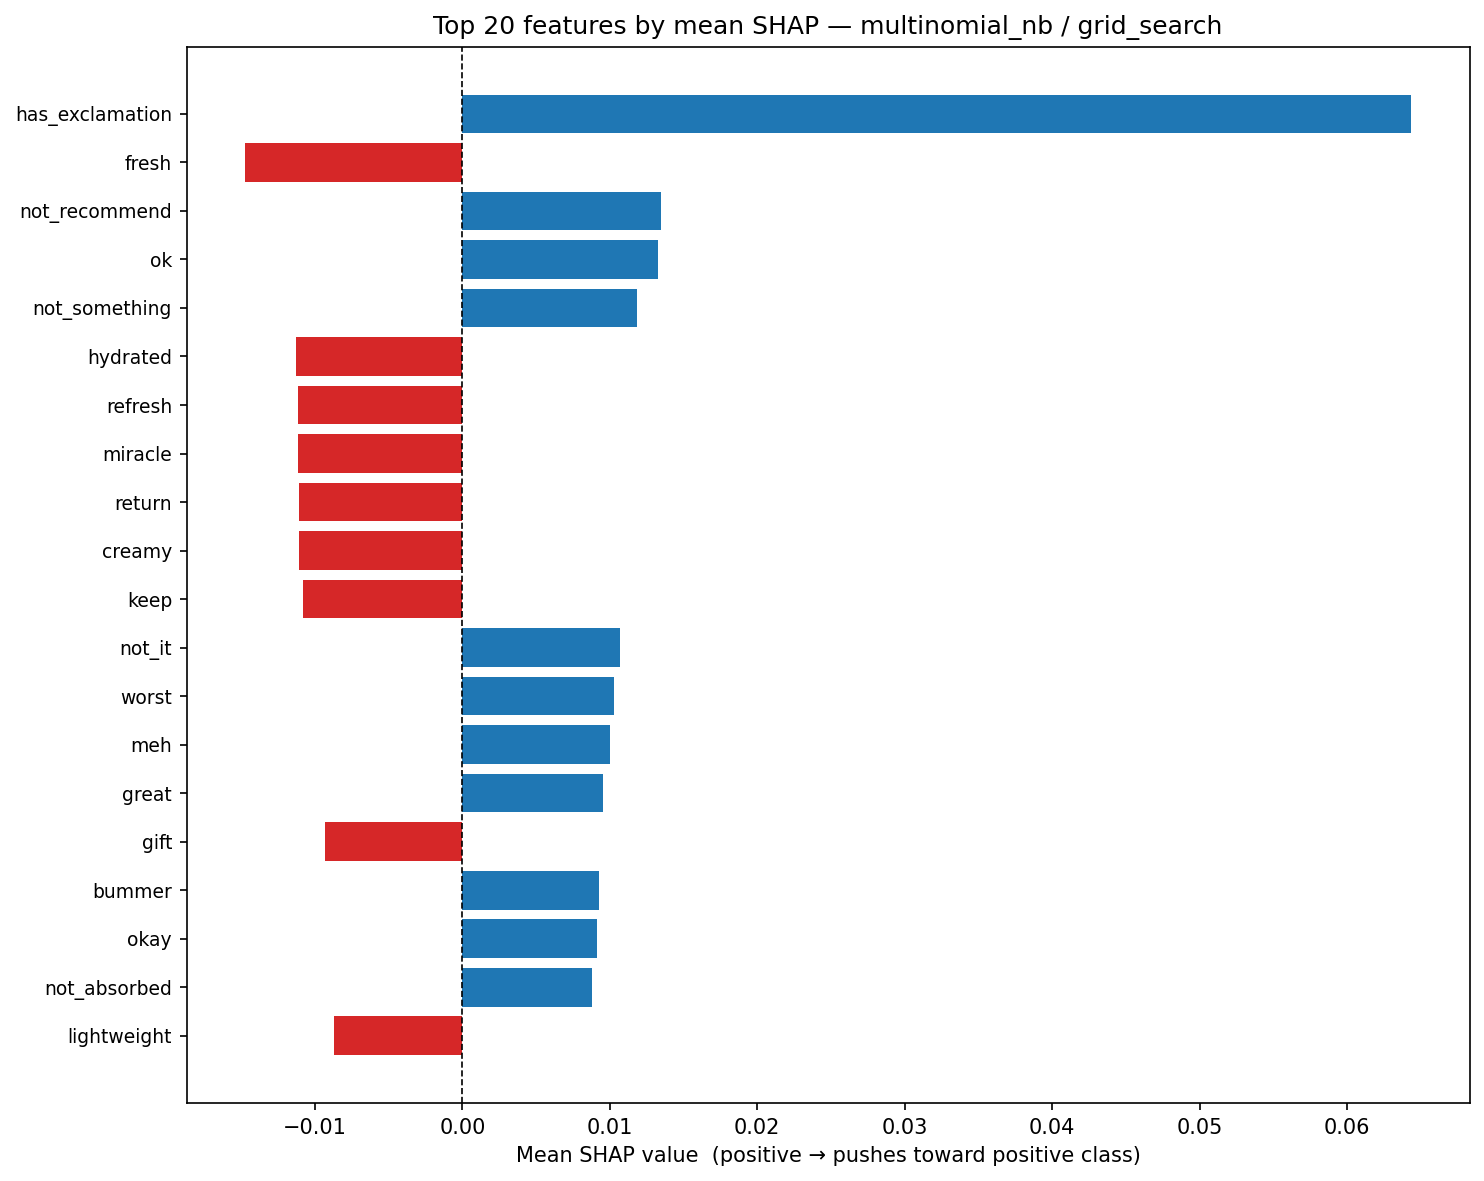

In [8]:
for i, (model, method, label) in enumerate(MODELS, start=1):
    display(Markdown(f"### 3.{i} {label}"))
    display(shap_image(model, "feature_importance.png"))

### Comparison

**Shared**: All three rank has_exclamation and great highest; amazing, worth, ok, not_recommend are consistently positive, while fresh, miracle, refresh, return, keep are consistently negative (likely from "had to return" contexts, etc). R

**Differences**: LR and NB assign much larger magnitudes (~0.06) than SVC (~0.019). LR uniquely elevates category metadata (Treatments, Eye Care, Moisturizers); NB leans on explicit negative tokens (worst, meh, bummer, not_absorbed); SVC stays purely lexical/affective with almost no metadata.

**Takeaway**: Same core vocabulary, different weighting — LR uses metadata, NB captures explicit negativity, SVC focuses on affective words.

## 4. Task 2c — Misclassified examples analysis

We will only explore the `LinearSVC` model here for brevity, but the same process can be repeated for the other two.

### 4.1 LinearSVC

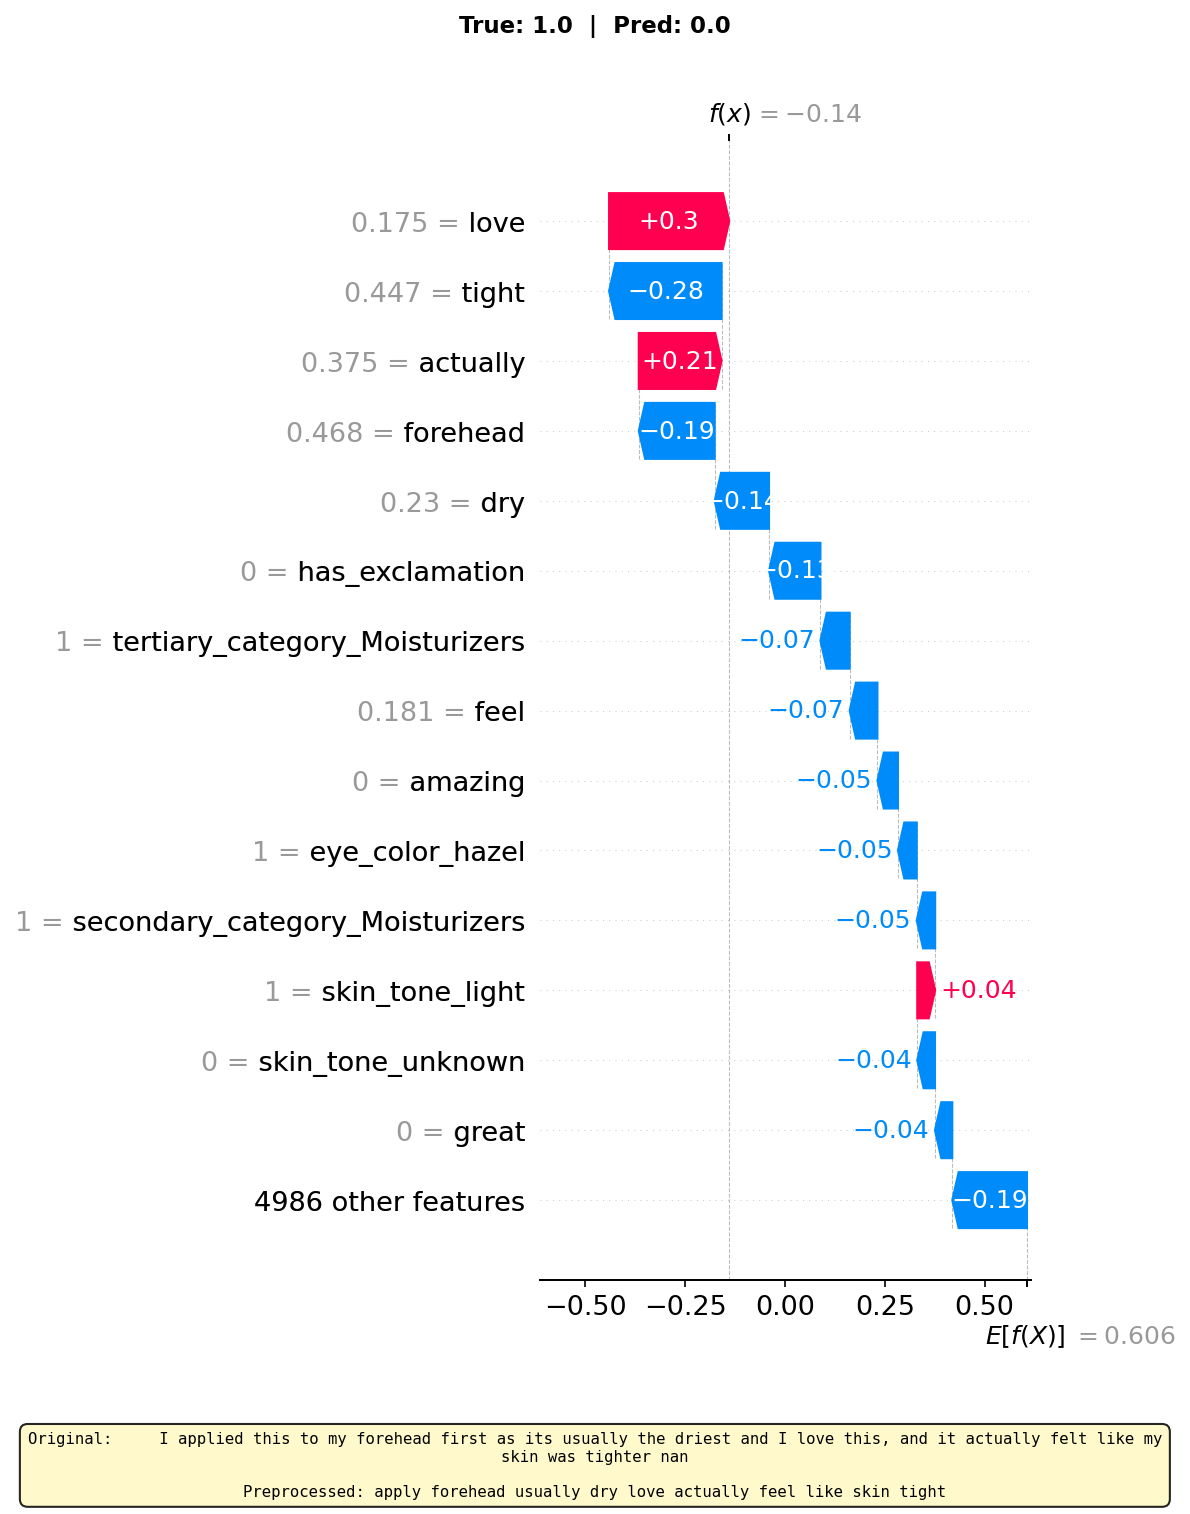

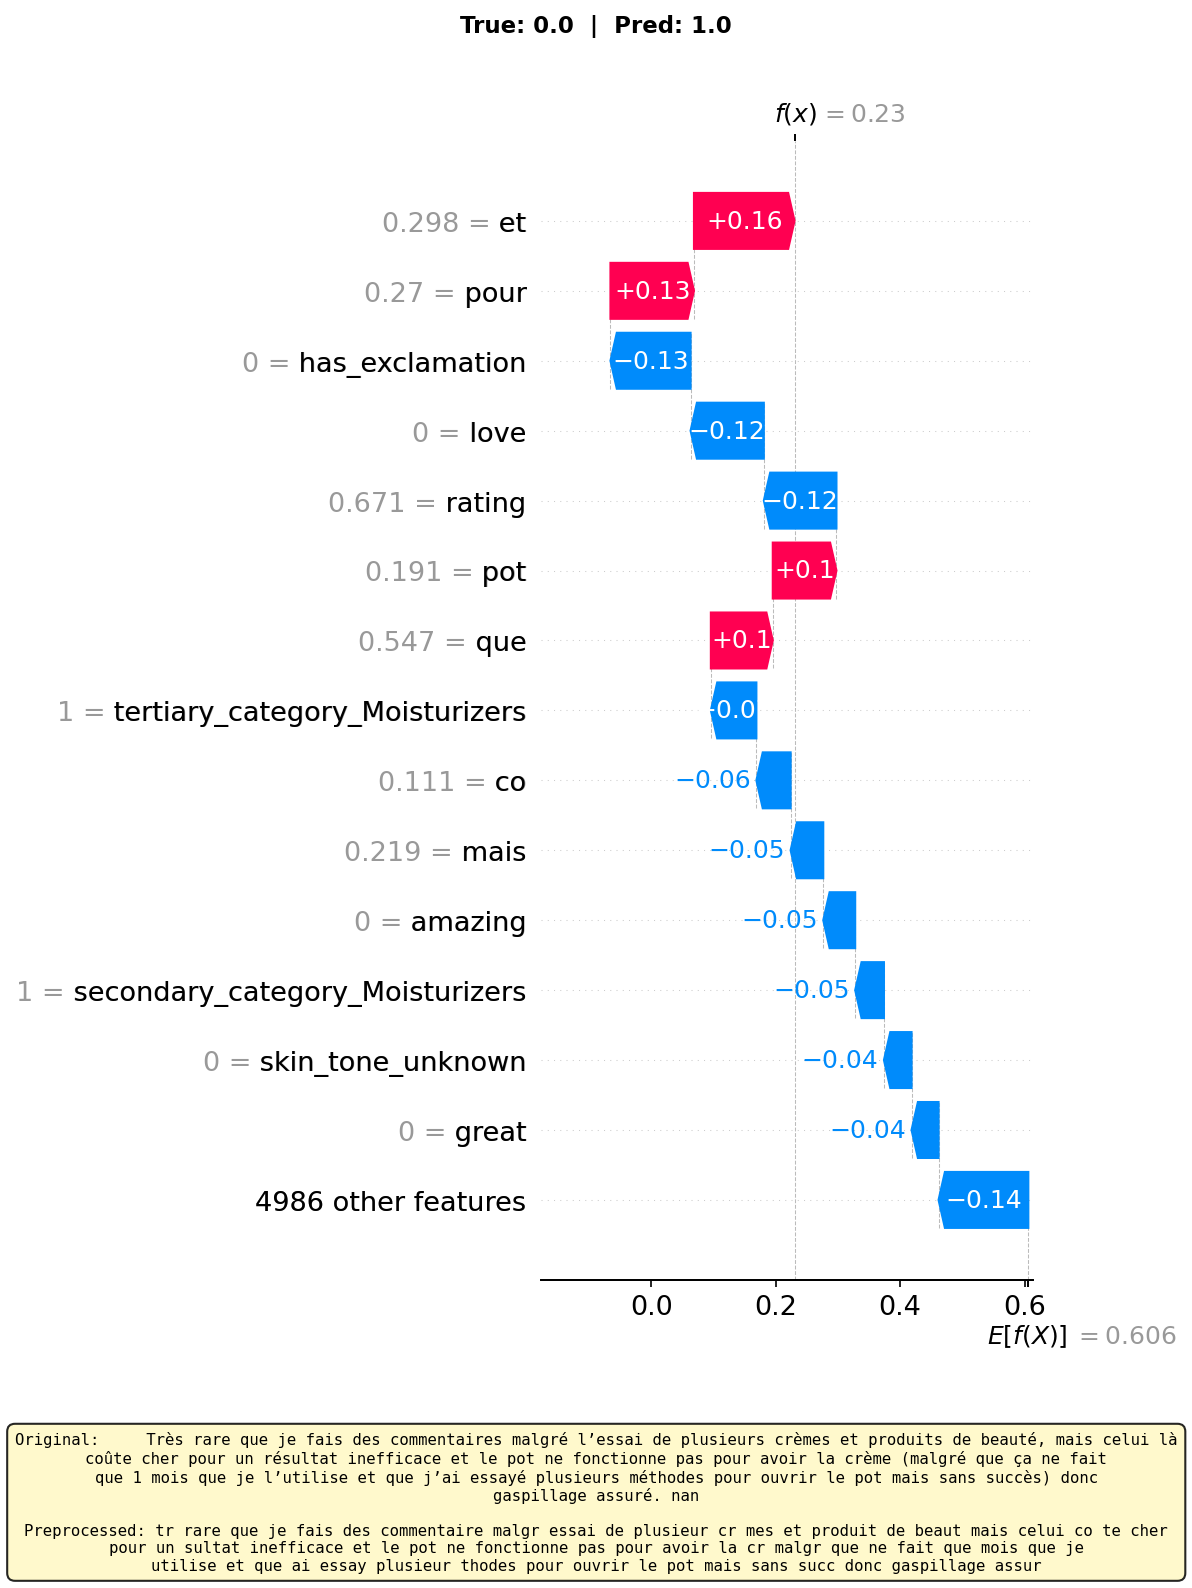

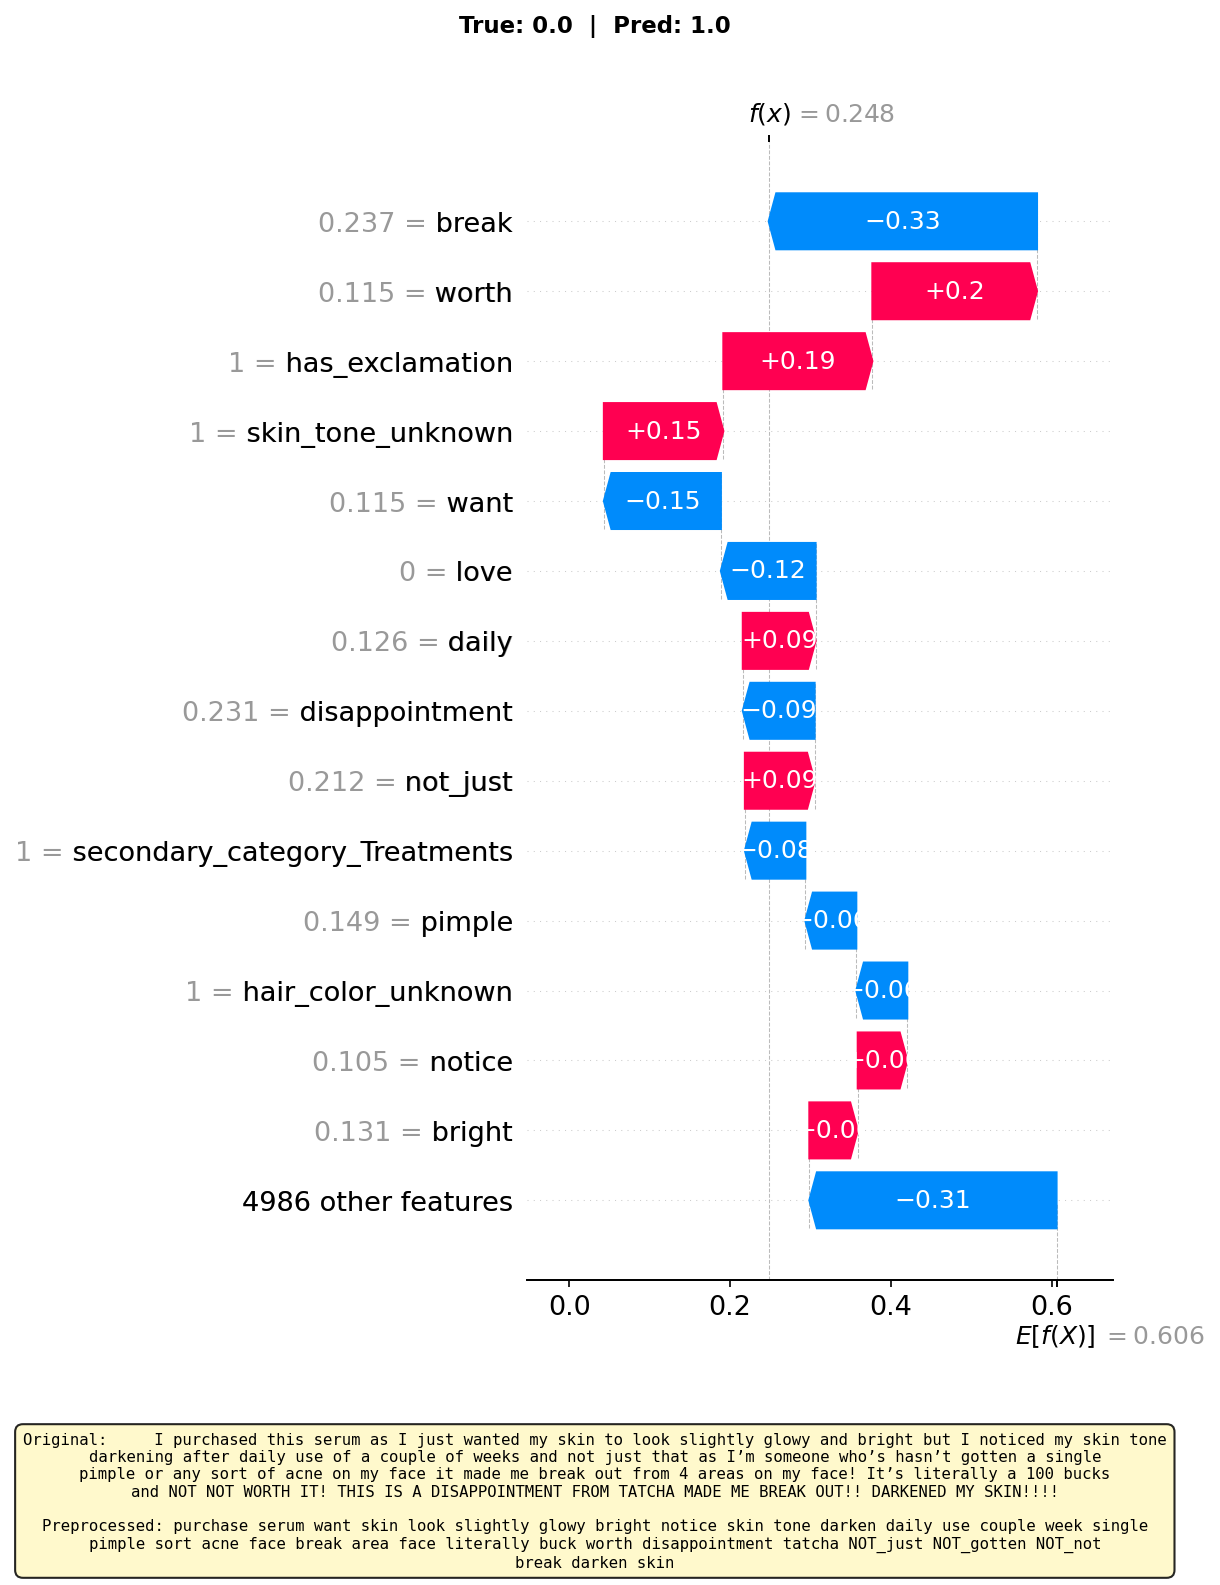

In [9]:
for i in range(3):
    display(shap_image("linear_svc", f"misclassified/example_{i:02d}.png"))


### Example 1
 What went wrong: The model was pushed negative by tight (−0.28) and forehead (−0.19) — "tight" usually signals skin discomfort, but here it's used positively ("firming"). The positive cue love (+0.3) wasn't strong enough to overcome it, and dry also contributed negatively despite appearing in a neutral descriptive context.

How to fix: Use bigrams like felt_tight / skin_tight so the model can disambiguate "tight = firming" from "tight = uncomfortable".
### Example 2
 What went wrong: Review is in French, but the English-trained model can't parse it. It latched onto French tokens et (+0.16), pour (+0.13), que (+0.1) as if they were features, and the absence of negative English cues (no has_exclamation, no love) wasn't enough to flip it negative.

How to fix: Filter or translate non-English reviews before training, or use a multilingual model  so foreign-language sentiment can actually be understood.

### Example 3
 What went wrong: Review complains about a serum causing a pimple and darkening skin, but the model was misled by has_exclamation (+0.19), worth (+0.2), and skin_tone_unknown (+0.15). The strong negative cue break (−0.33) wasn't enough to overcome them, and nuanced phrases like "disappointment" and "not_just" had only weak impact.

How to fix: Down-weight has_exclamation as a positive signal (exclamations appear in negative reviews too), and use n-grams / negation-aware features so "break out", "darken skin", "disappointment" carry stronger negative weight.